In [1]:
"""
Visualization of CostRev4 Piecewise Linear Functions and Coefficients

This notebook provides comprehensive visualization of the piecewise linear functions
and model coefficients from the CostRev4 cost model used in the batch SGD pipeline.

Features:
- Load trained model from checkpoint or create a new one
- Plot piecewise linear functions for airspace charge and wind components
- Display all model coefficients (beta parameters)
- Analyze the cost function behavior across different input ranges
- Show the impact of different components on the total cost
"""

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
from typing import Optional, Tuple, Dict, Any

# Add project root to path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import the cost model
from src.equinox.cost.cost_rev4 import CostRev4, DEFAULT_KNOTS_AC_DIST, DEFAULT_KNOTS_WIND

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"Default AC*Dist knots: {DEFAULT_KNOTS_AC_DIST}")
print(f"Default Wind knots: {DEFAULT_KNOTS_WIND}")


✓ Imports successful
Project root: d:\project-equinox
Default AC*Dist knots: [0.0, 25.0, 50.0, 100.0, 200.0]
Default Wind knots: [-60.0, -40.0, -20.0, -10.0, 0.0, 10.0, 20.0, 40.0, 60.0]


In [2]:
def load_trained_model(case_dir: str = "data/cases/LEMD_EGLL", 
                       checkpoint_name: Optional[str] = None,
                       device: str = "cuda") -> Tuple[CostRev4, Dict[str, Any]]:
    """
    Load a trained CostRev4 model from checkpoint.
    
    Args:
        case_dir: Directory containing the case data and results
        checkpoint_name: Specific checkpoint file name, or None to load latest
        device: Device to load the model on
        
    Returns:
        Tuple of (loaded_model, checkpoint_info)
    """
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    
    # Look for batch SGD results directory
    results_dir = Path(case_dir) / "batch_sgd_results"
    print(f'Results Directory: {results_dir}')
    
    if results_dir.exists():
        # Find checkpoint files
        checkpoints = list(results_dir.glob("checkpoint_iter_*.pt"))

        print(f'Found {len(checkpoints)} potential checkpoints')
        
        if checkpoints:
            if checkpoint_name:
                checkpoint_path = results_dir / checkpoint_name
                print(f'Attempting to load checkpoint from {checkpoint_path}')
                if not checkpoint_path.exists():
                    print(f"Specified checkpoint {checkpoint_name} not found")
                    checkpoint_path = None
            else:
                # Find latest checkpoint by iteration number
                checkpoint_nums = []
                for cp in checkpoints:
                    try:
                        num = int(cp.stem.split('_')[-1])
                        checkpoint_nums.append((num, cp))
                    except ValueError:
                        continue
                
                if checkpoint_nums:
                    checkpoint_path = max(checkpoint_nums, key=lambda x: x[0])[1]
                    print(f"Loading latest checkpoint: {checkpoint_path.name}")
                else:
                    checkpoint_path = None

            
            
            if checkpoint_path and checkpoint_path.exists():
                # Load checkpoint with weights_only=False to handle numpy scalars
                try:
                    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
                except Exception as e:
                    print(f"Failed to load checkpoint with weights_only=False: {e}")
                    # Try with safe globals as alternative
                    try:
                        import numpy as np
                        torch.serialization.add_safe_globals([np.core.multiarray.scalar])
                        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
                    except Exception as e2:
                        print(f"Failed to load checkpoint with safe globals: {e2}")
                        checkpoint = None
                
                if checkpoint:
                    # Create model with same architecture
                    # We need to infer the number of waypoints - use a reasonable default
                    num_waypoints = 1000  # This should match your actual graph size
                    
                    cost_model = CostRev4(
                        beta0=0.0, beta1=1e-2, beta2=0.0, beta3=1.0,
                        num_waypoints=num_waypoints,
                        alpha_pref_reg=1.0,
                        device=device
                    )
                    
                    # Load state dict
                    model_state_dict = checkpoint['model_state_dict']
                    # beta0 is not a parameter in CostRev4 (it's a constant 0.0), so we need to handle missing keys
                    cost_model.load_state_dict(model_state_dict, strict=False)
                    cost_model.eval()
                    
                    print(f"✓ Loaded trained model from {checkpoint_path.name}")
                    print(f"  Training iteration: {checkpoint['iteration']}")
                    
                    return cost_model, checkpoint
    
    # If no checkpoint found, create a new model with default parameters
    print("No trained model found. Creating new model with default parameters.")
    cost_model = CostRev4(
        beta0=0.1, beta1=1e-2, beta2=-0.1, beta3=1.0,
        num_waypoints=1000,
        alpha_pref_reg=1.0,
        device=device
    )
    cost_model.eval()
    
    return cost_model, {}

# Try to load a trained model
try:
    cost_model, checkpoint_info = load_trained_model(case_dir='../data/cases/LEMD_EGLL')
    print(f"Model device: {cost_model.device}")
    print(f"Model coefficients loaded: {len(list(cost_model.parameters()))} parameters")
except Exception as e:
    print(f"Error loading model: {e}")
    # Create a simple model for demonstration
    cost_model = CostRev4(
        beta0=0.1, beta1=1e-2, beta2=-0.1, beta3=1.0,
        num_waypoints=100, alpha_pref_reg=1.0
    )
    checkpoint_info = {}
    print("Created demonstration model with example parameters")


Results Directory: ..\data\cases\LEMD_EGLL\batch_sgd_results
Found 5 potential checkpoints
Loading latest checkpoint: checkpoint_iter_50.pt
✓ Loaded trained model from checkpoint_iter_50.pt
  Training iteration: 50
Model device: cpu
Model coefficients loaded: 5 parameters


In [3]:
def print_model_coefficients(model: CostRev4, title: str = "Model Coefficients"):
    """
    Print all model coefficients in a formatted way.
    
    Args:
        model: The CostRev4 model
        title: Title for the output
    """
    print(f"\n{'='*50}")
    print(f"{title:^50}")
    print(f"{'='*50}")
    
    # Beta coefficients - CostRev4 has different structure
    print(f"Beta Coefficients:")
    print(f"  β₀ (intercept):     {model.beta0:>12.6f}")
    print(f"  β₁ (AC*dist coeff): {'Fixed at 1.0 (implicit)':>12}")  
    print(f"  β₂ (wind coeff):    {'Fixed at 1.0 (implicit)':>12}")
    # β₃ is commented out in CostRev4
    # print(f"  β₃ (preference):    {'Not used':>12}")
    
    # Regularization parameter
    print(f"\nRegularization:")
    print(f"  α (pref reg):       {model.alpha_pref_reg.item():>12.6f}")
    
    # Note about preference matrix
    print(f"\nPreference Matrix:")
    print(f"  Status:             {'Disabled in CostRev4':>12}")
    
    # Piecewise linear model parameters
    print(f"\nAirspace Charge PLM (monotonic {model.plm_ac_dist.monotonic_type}):")
    print(f"  Knot points:        {model.plm_ac_dist.knot_points.tolist()}")
    
    # Check if initial_intercept exists and is not None
    if hasattr(model.plm_ac_dist, 'initial_intercept') and model.plm_ac_dist.initial_intercept is not None:
        print(f"  Initial intercept:  {model.plm_ac_dist.initial_intercept.item():>12.6f}")
    else:
        print(f"  Initial intercept:  {'Not available':>12}")
    
    # Check if first_slope exists and is not None
    if hasattr(model.plm_ac_dist, 'first_slope') and model.plm_ac_dist.first_slope is not None:
        print(f"  First slope:        {model.plm_ac_dist.first_slope.item():>12.6f}")
    else:
        print(f"  First slope:        {'Not available':>12}")
    
    if model.plm_ac_dist.knot_points.numel() > 0:
        if hasattr(model.plm_ac_dist, 'unconstrained_slope_increments'):
            print(f"  Slope increments:   {model.plm_ac_dist.unconstrained_slope_increments.data.tolist()}")
        if hasattr(model.plm_ac_dist, 'get_slopes'):
            slopes = model.plm_ac_dist.get_slopes()
            print(f"  Actual slopes:      {slopes.tolist()}")
    
    print(f"\nWind PLM (monotonic {model.plm_wind.monotonic_type}):")
    print(f"  Knot points:        {model.plm_wind.knot_points.tolist()}")
    print(f"  Input scaling:      distance/450.0 × tailwind")
    
    # Check if initial_intercept exists and is not None
    if hasattr(model.plm_wind, 'initial_intercept') and model.plm_wind.initial_intercept is not None:
        print(f"  Initial intercept:  {model.plm_wind.initial_intercept.item():>12.6f}")
    else:
        print(f"  Initial intercept:  {'Not available':>12}")
    
    # Check if first_slope exists and is not None
    if hasattr(model.plm_wind, 'first_slope') and model.plm_wind.first_slope is not None:
        print(f"  First slope:        {model.plm_wind.first_slope.item():>12.6f}")
    else:
        print(f"  First slope:        {'Not available':>12}")
    
    if model.plm_wind.knot_points.numel() > 0:
        if hasattr(model.plm_wind, 'unconstrained_slope_increments'):
            print(f"  Slope increments:   {model.plm_wind.unconstrained_slope_increments.data.tolist()}")
        if hasattr(model.plm_wind, 'get_slopes'):
            slopes = model.plm_wind.get_slopes()
            print(f"  Actual slopes:      {slopes.tolist()}")
    
    # CostRev4 specific formula
    print(f"\nCostRev4 Formula:")
    print(f"  cost = β₀ + PLM_ac(AC×dist/100) + PLM_wind(dist/450×tailwind)")
    print(f"  Where:")
    print(f"    - AC×dist/100: airspace charge × distance / 100")
    print(f"    - dist/450×tailwind: distance-weighted tailwind effect")
    
    print(f"{'='*50}\n")

# Print the coefficients
print_model_coefficients(cost_model, "CostRev4 Model Coefficients")


           CostRev4 Model Coefficients            
Beta Coefficients:
  β₀ (intercept):         0.000000
  β₁ (AC*dist coeff): Fixed at 1.0 (implicit)
  β₂ (wind coeff):    Fixed at 1.0 (implicit)

Regularization:
  α (pref reg):           1.000000

Preference Matrix:
  Status:             Disabled in CostRev4

Airspace Charge PLM (monotonic non_decreasing):
  Knot points:        [0.0, 25.0, 50.0, 100.0, 200.0]
  Initial intercept:  Not available
  First slope:            0.318058
  Slope increments:   [-0.9822799563407898, -8.381620407104492, -8.991576194763184, -9.608634948730469, -9.252817153930664]
  Actual slopes:      [0.3180582821369171, 0.6361165642738342, 0.6363455653190613, 0.6364700198173523, 0.6365371346473694, 0.6366329789161682]

Wind PLM (monotonic non_increasing):
  Knot points:        [-60.0, -40.0, -20.0, -10.0, 0.0, 10.0, 20.0, 40.0, 60.0]
  Input scaling:      distance/450.0 × tailwind
  Initial intercept:  Not available
  First slope:           -0.000412
  Slope i

Plotting Airspace Charge Piecewise Linear Function...


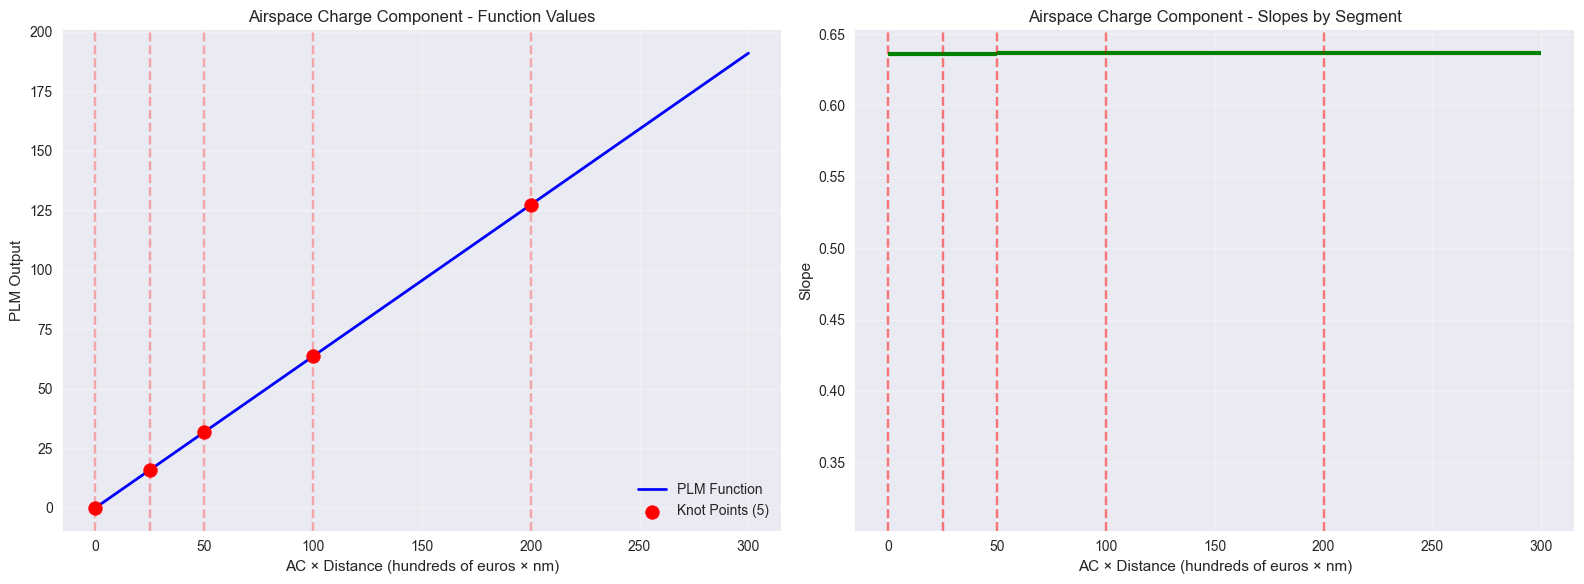

Plotting Wind Piecewise Linear Function...


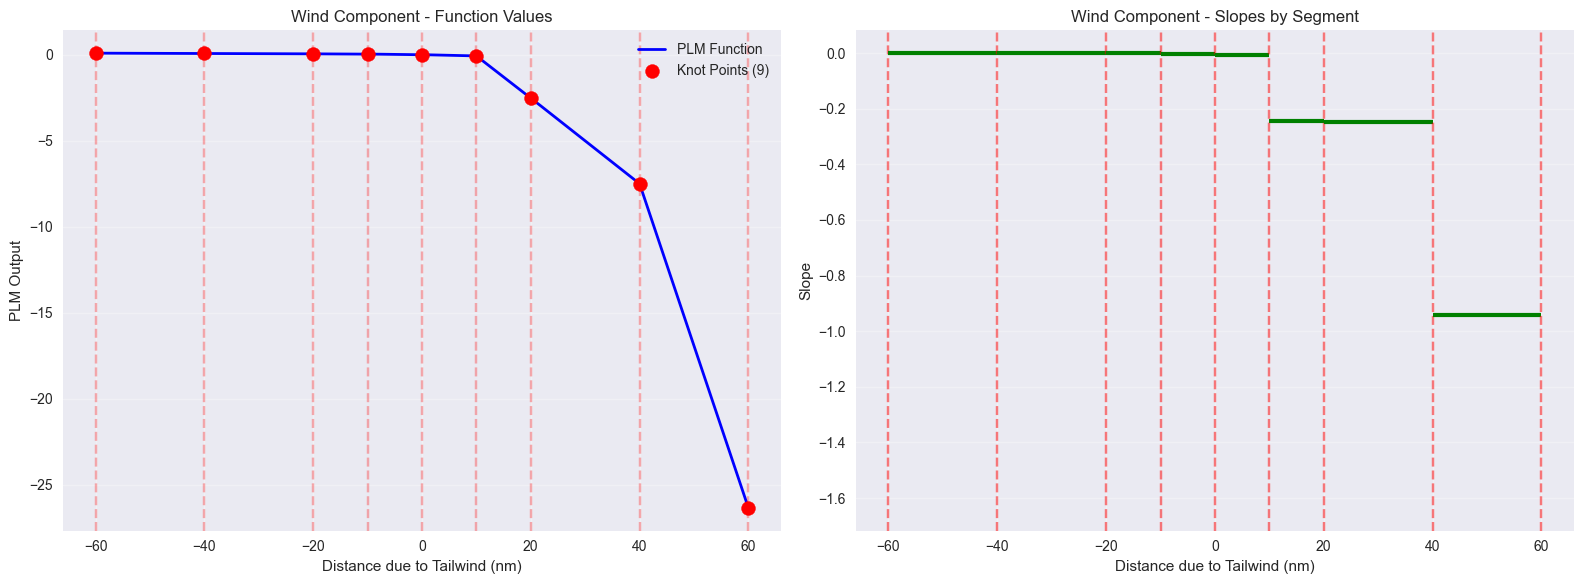


Note: In CostRev4, wind input is transformed as:
distance_due_to_tailwind = (segment_distance / 450.0) × tailwind_knots
The plot above shows the PLM response to this transformed input.


In [4]:
def plot_piecewise_linear_function(plm, x_range: Tuple[float, float], 
                                   title: str, xlabel: str, ylabel: str,
                                   num_points: int = 1000, y_min: float = None, y_max: float = None) -> plt.Figure:
    """
    Plot a piecewise linear monotonic function.
    
    Args:
        plm: PiecewiseLinearMonoModel instance
        x_range: Tuple of (min_x, max_x) for plotting range
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        num_points: Number of points to evaluate
        
    Returns:
        matplotlib Figure object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Generate x values
    x_min, x_max = x_range
    x_vals = torch.linspace(x_min, x_max, num_points)
    
    # Evaluate the function
    with torch.no_grad():
        y_vals = plm(x_vals)
    
    # Convert to numpy for plotting (detach all tensors)
    x_np = x_vals.detach().cpu().numpy()
    y_np = y_vals.detach().cpu().numpy()
    
    # Plot 1: Function values
    ax1.plot(x_np, y_np, 'b-', linewidth=2, label='PLM Function')
    
    # Mark knot points
    if plm.knot_points.numel() > 0:
        knot_x = plm.knot_points.detach().cpu().numpy()
        knot_y = plm(plm.knot_points.detach()).detach().cpu().numpy()
        ax1.scatter(knot_x, knot_y, c='red', s=100, zorder=5, 
                   label=f'Knot Points ({len(knot_x)})')
        
        # Add vertical lines at knots
        for kx in knot_x:
            ax1.axvline(x=kx, color='red', alpha=0.3, linestyle='--')
    
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(f'{title} - Function Values')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Set y-axis limits if provided
    if y_min is not None and y_max is not None:
        ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Slopes
    if plm.knot_points.numel() > 0:
        slopes = plm.get_slopes().detach().cpu().numpy()
        knot_points = plm.knot_points.detach().cpu().numpy()
        
        # Create x positions for slopes (including boundaries)
        x_positions = [x_min] + knot_points.tolist() + [x_max]
        
        # Plot slopes as step function
        for i, slope in enumerate(slopes):
            x_start = x_positions[i]
            x_end = x_positions[i + 1]
            ax2.hlines(slope, x_start, x_end, colors='green', linewidth=3,
                      label=f'Slope {i+1}: {slope:.4f}' if i < 3 else None)
            
            # Mark slope changes
            if i < len(slopes) - 1:
                ax2.axvline(x=x_end, color='red', alpha=0.5, linestyle='--')
        
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel('Slope')
        ax2.set_title(f'{title} - Slopes by Segment')
        ax2.grid(True, alpha=0.3)
        if len(slopes) <= 3:
            ax2.legend()
    else:
        # Single slope case
        slope = plm.get_slopes().detach().item()
        ax2.axhline(y=slope, color='green', linewidth=3, 
                   label=f'Constant Slope: {slope:.4f}')
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel('Slope')
        ax2.set_title(f'{title} - Constant Slope')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
    
    plt.tight_layout()
    return fig

# Plot the airspace charge component (unchanged from CostRev3)
print("Plotting Airspace Charge Piecewise Linear Function...")
fig_ac = plot_piecewise_linear_function(
    cost_model.plm_ac_dist,
    x_range=(0, 300),  # Range for AC*distance (hundreds of euros * nm)
    title="Airspace Charge Component",
    xlabel="AC × Distance (hundreds of euros × nm)",
    ylabel="PLM Output"
)
plt.show()

print("Plotting Wind Piecewise Linear Function...")
fig_wind = plot_piecewise_linear_function(
    cost_model.plm_wind,
    x_range=(-60, 60),  # Updated range to match CostRev4 knots
    title="Wind Component", 
    xlabel="Distance due to Tailwind (nm)",  # Updated label for CostRev4
    ylabel="PLM Output"
)
plt.show()

print("\nNote: In CostRev4, wind input is transformed as:")
print("distance_due_to_tailwind = (segment_distance / 450.0) × tailwind_knots")
print("The plot above shows the PLM response to this transformed input.")

Analyzing cost component contributions...

Component Analysis at Sample Points:
(Reference distance: 450.0nm)
    Point  Intercept  AC Component  Wind Component   Total
(10, -20)     0.0000        6.3612          0.0478  6.4089
  (50, 0)     0.0000       31.8116         -0.0000 31.8116
(100, 20)     0.0000       63.6351         -2.5199 61.1152
(150, 40)     0.0000       95.4619         -7.5029 87.9590


C:\Users\hoang\AppData\Local\Temp\ipykernel_19656\1255327539.py:135: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\hoang\anaconda3\envs\equinox\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


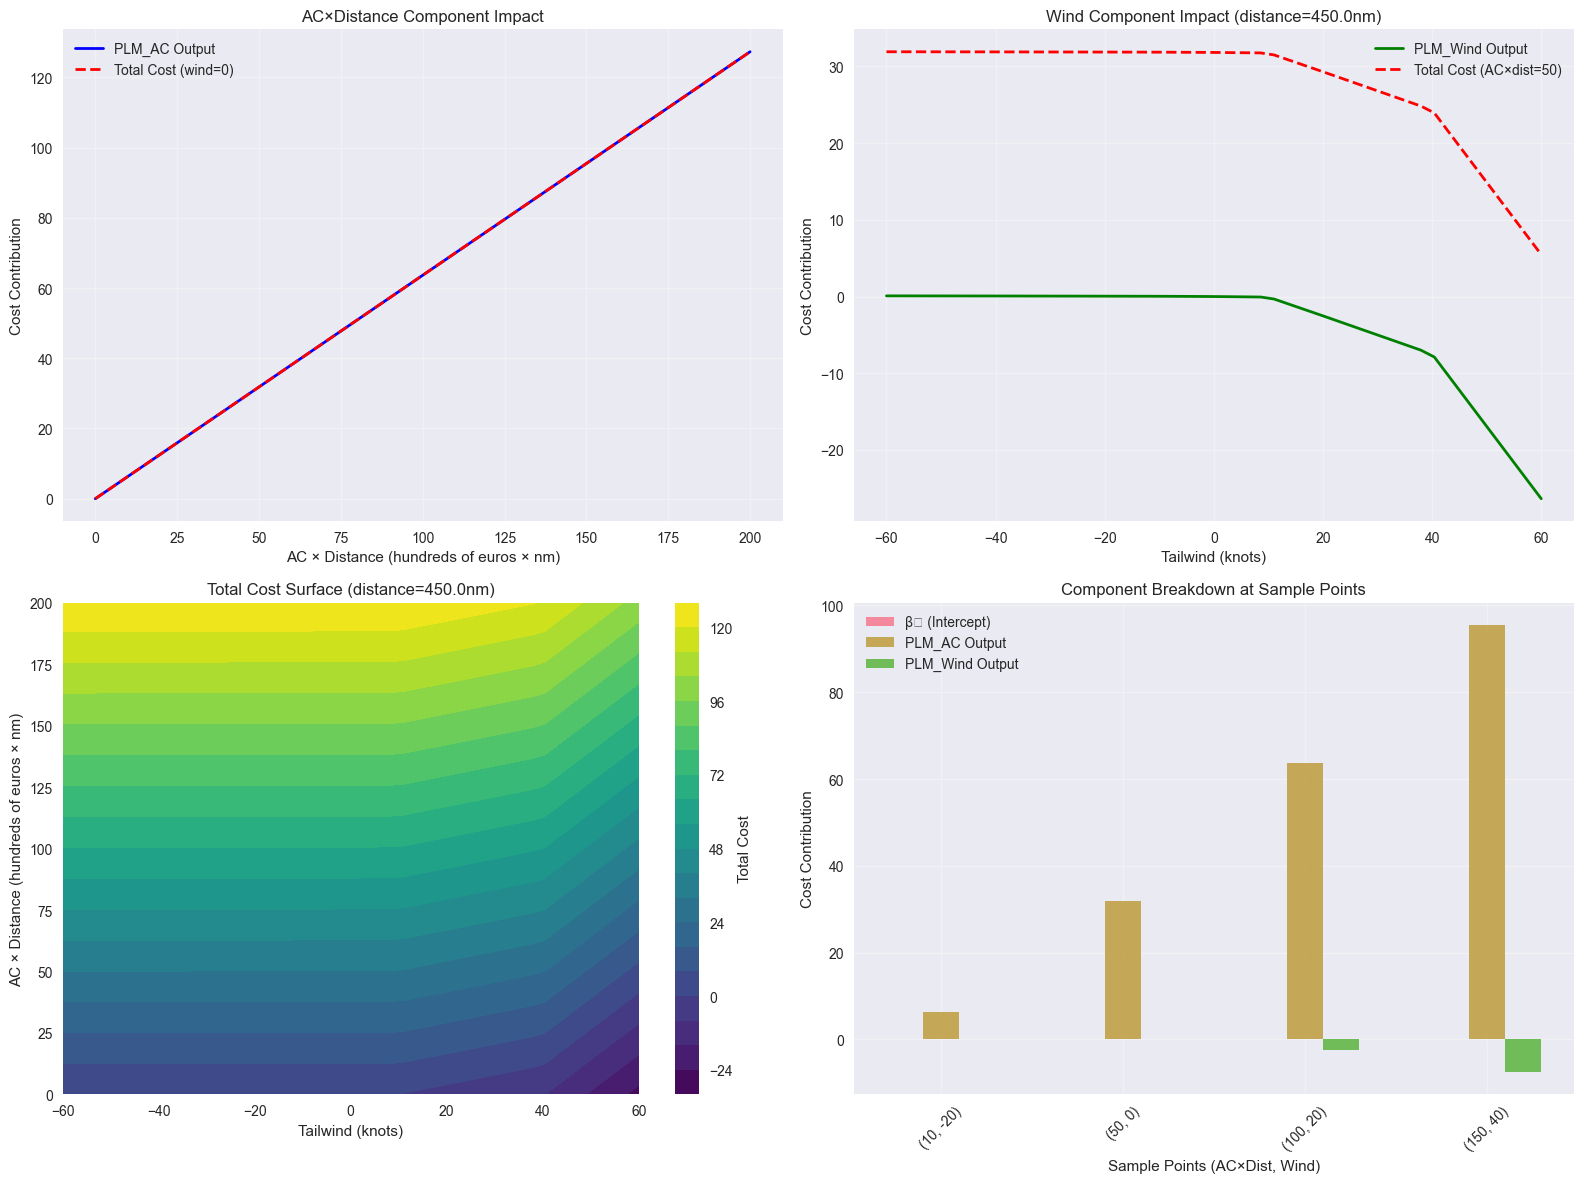

In [5]:
def analyze_cost_components(model: CostRev4, 
                           ac_dist_range: Tuple[float, float] = (0, 200),
                           wind_range: Tuple[float, float] = (-60, 60),
                           num_points: int = 50,
                           reference_distance: float = 450.0) -> plt.Figure:
    """
    Analyze how different components contribute to the total cost.
    
    Args:
        model: CostRev4 model
        ac_dist_range: Range for AC*distance values
        wind_range: Range for wind values (knots)
        num_points: Number of points to evaluate
        reference_distance: Distance to use for wind component analysis (nm)
        
    Returns:
        matplotlib Figure object
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Generate test ranges
    ac_dist_vals = torch.linspace(ac_dist_range[0], ac_dist_range[1], num_points)
    wind_vals = torch.linspace(wind_range[0], wind_range[1], num_points)
    
    with torch.no_grad():
        # Component 1: AC*Distance contribution vs AC*Distance (fixed wind=0)
        wind_fixed = torch.zeros_like(ac_dist_vals)
        ac_component = model.plm_ac_dist(ac_dist_vals)
        # In CostRev4, wind component depends on distance, so use reference_distance
        distance_due_to_wind_fixed = reference_distance / 450.0 * wind_fixed
        wind_component_fixed = model.plm_wind(distance_due_to_wind_fixed)
        total_cost_ac_var = model.beta0 + ac_component + wind_component_fixed
        
        axes[0,0].plot(ac_dist_vals.cpu(), ac_component.cpu(), 'b-', linewidth=2, 
                      label='PLM_AC Output')
        axes[0,0].plot(ac_dist_vals.cpu(), total_cost_ac_var.cpu(), 'r--', linewidth=2,
                      label='Total Cost (wind=0)')
        axes[0,0].set_xlabel('AC × Distance (hundreds of euros × nm)')
        axes[0,0].set_ylabel('Cost Contribution')
        axes[0,0].set_title('AC×Distance Component Impact')
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].legend()
        
        # Component 2: Wind contribution vs Wind (fixed AC*dist=50)
        ac_dist_fixed = torch.full_like(wind_vals, 50.0)
        # In CostRev4: distance_due_to_tailwind = distance / 450.0 * tailwind
        distance_due_to_wind = reference_distance / 450.0 * wind_vals
        wind_component = model.plm_wind(distance_due_to_wind)
        ac_component_fixed = model.plm_ac_dist(ac_dist_fixed)
        total_cost_wind_var = model.beta0 + ac_component_fixed + wind_component
        
        axes[0,1].plot(wind_vals.cpu(), wind_component.cpu(), 'g-', linewidth=2,
                      label='PLM_Wind Output')
        axes[0,1].plot(wind_vals.cpu(), total_cost_wind_var.cpu(), 'r--', linewidth=2,
                      label='Total Cost (AC×dist=50)')
        axes[0,1].set_xlabel('Tailwind (knots)')
        axes[0,1].set_ylabel('Cost Contribution')
        axes[0,1].set_title(f'Wind Component Impact (distance={reference_distance}nm)')
        axes[0,1].grid(True, alpha=0.3)
        axes[0,1].legend()
        
        # Component 3: Cost surface (heatmap)
        AC_DIST, WIND = torch.meshgrid(ac_dist_vals, wind_vals, indexing='ij')
        
        ac_dist_flat = AC_DIST.flatten()
        wind_flat = WIND.flatten()
        
        # Compute the PLM outputs using CostRev4 formula
        plm_ac_out = model.plm_ac_dist(ac_dist_flat)
        distance_due_to_wind_flat = reference_distance / 450.0 * wind_flat
        plm_wind_out = model.plm_wind(distance_due_to_wind_flat)
        
        # Use the actual formula from CostRev4 forward method
        total_cost_flat = model.beta0 + plm_ac_out + plm_wind_out
        
        total_cost_surface = total_cost_flat.reshape(AC_DIST.shape)
        
        im = axes[1,0].contourf(WIND.cpu(), AC_DIST.cpu(), total_cost_surface.cpu(), 
                               levels=20, cmap='viridis')
        axes[1,0].set_xlabel('Tailwind (knots)')
        axes[1,0].set_ylabel('AC × Distance (hundreds of euros × nm)')
        axes[1,0].set_title(f'Total Cost Surface (distance={reference_distance}nm)')
        plt.colorbar(im, ax=axes[1,0], label='Total Cost')
        
        # Component 4: Component contributions at different points
        sample_points = [(10, -20), (50, 0), (100, 20), (150, 40)]
        components_data = []
        
        for ac_dist, wind in sample_points:
            ac_dist_tensor = torch.tensor([ac_dist], dtype=torch.float32)
            wind_tensor = torch.tensor([wind], dtype=torch.float32)
            
            plm_ac = model.plm_ac_dist(ac_dist_tensor)
            # Apply CostRev4 wind transformation
            distance_due_to_wind_tensor = reference_distance / 450.0 * wind_tensor
            plm_wind = model.plm_wind(distance_due_to_wind_tensor)
            
            ac_component = plm_ac
            wind_component = plm_wind
            intercept = model.beta0
            
            components_data.append({
                'Point': f'({ac_dist}, {wind})',
                'Intercept': intercept,
                'AC Component': ac_component.item(),
                'Wind Component': wind_component.item(),
                'Total': (intercept + ac_component + wind_component).item()
            })
        
        # Create bar chart
        df_components = pd.DataFrame(components_data)
        x_pos = np.arange(len(sample_points))
        width = 0.2
        
        axes[1,1].bar(x_pos - width, df_components['Intercept'], width, 
                     label='β₀ (Intercept)', alpha=0.8)
        axes[1,1].bar(x_pos, df_components['AC Component'], width,
                     label='PLM_AC Output', alpha=0.8)
        axes[1,1].bar(x_pos + width, df_components['Wind Component'], width,
                     label='PLM_Wind Output', alpha=0.8)
        
        axes[1,1].set_xlabel('Sample Points (AC×Dist, Wind)')
        axes[1,1].set_ylabel('Cost Contribution')
        axes[1,1].set_title('Component Breakdown at Sample Points')
        axes[1,1].set_xticks(x_pos)
        axes[1,1].set_xticklabels(df_components['Point'], rotation=45)
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        # Print the numerical values
        print("\nComponent Analysis at Sample Points:")
        print(f"(Reference distance: {reference_distance}nm)")
        print(df_components.to_string(index=False, float_format='%.4f'))
    
    plt.tight_layout()
    return fig

# Analyze cost components
print("Analyzing cost component contributions...")
fig_analysis = analyze_cost_components(cost_model)
plt.show()
